# Module 6 — Data Wrangling Part I (Cleaning)

In this notebook, I convert my IPL player–match datasets into **analysis-ready** tables.

**Goal:** Make the data consistent, reproducible, and ready for modeling by:
- fixing data types (dates, numeric columns)
- standardizing categorical labels (stage_bucket)
- checking and removing duplicates using a clear uniqueness definition
- handling missing values with a justified plan (keep structural missingness)
- detecting obvious errors (negative values, impossible ranges)
- saving final cleaned outputs for future modeling

Outputs saved:
- `data/processed/batting_clean.csv`
- `data/processed/bowling_clean.csv`

In [ ]:
import os
from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1) Load the analysis tables

I load the four core tables from my SQLite database:
- `matches`
- `players`
- `player_match_batting`
- `player_match_bowling`

I keep the pipeline reproducible by checking that the database exists before reading.

In [ ]:

DATA_DIR = Path("/content")

DB_PATH = DATA_DIR / "ipl_cricket_only.db"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Missing DB: {DB_PATH}\n"
        "If using Colab: upload ipl_cricket_only.db to /content.\n"
        "If local: set DATA_DIR to your repo root."
    )

con = sqlite3.connect(DB_PATH)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", con)
print("Tables:", tables["name"].tolist())

matches = pd.read_sql_query("SELECT * FROM matches;", con)
players = pd.read_sql_query("SELECT * FROM players;", con)
batting = pd.read_sql_query("SELECT * FROM player_match_batting;", con)
bowling = pd.read_sql_query("SELECT * FROM player_match_bowling;", con)

con.close()

print("\nLoaded shapes:")
print("matches :", matches.shape)
print("players :", players.shape)
print("batting :", batting.shape)
print("bowling :", bowling.shape)

Tables: ['matches', 'players', 'player_match_batting', 'player_match_bowling']

Loaded shapes:
matches : (1095, 21)
players : (732, 1)
batting : (16515, 11)
bowling : (12978, 17)


## 2) Before-cleaning checks (baseline)

Before making changes, I document:
- data types (`.info()`)
- missingness (%)
- duplicates (based on my uniqueness definition)
- basic category counts for match stage

This creates a “before” snapshot that I can compare to the cleaned version.

In [ ]:
def missingness_table(df: pd.DataFrame) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False) * 100
    out = pd.DataFrame({"missing_%": miss.round(2)})
    return out[out["missing_%"] > 0]

def dup_count(df: pd.DataFrame, subset_cols: list[str]) -> int:
    return int(df.duplicated(subset=subset_cols).sum())

In [ ]:
print(" matches.info() ")
print(matches.info())

print("batting.info()")
print(batting.info())

print(" bowling.info() ")
print(bowling.info())

print(" Missingness (batting) ")
display(missingness_table(batting))

print("Missingness (bowling)")
display(missingness_table(bowling))

# Uniqueness definitions
bat_dups = dup_count(batting, ["match_id", "player"])
bowl_dups = dup_count(bowling, ["match_id", "bowler"])

print("\nDuplicate counts (BEFORE):")
print("batting duplicates by (match_id, player):", bat_dups)
print("bowling duplicates by (match_id, bowler):", bowl_dups)

print("\nStage counts (batting):")
print(batting["stage_bucket"].value_counts(dropna=False))

print("\nStage counts (bowling):")
print(bowling["stage_bucket"].value_counts(dropna=False))

 matches.info() 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 1

,missing_%


Missingness (bowling)


,missing_%
strike_rate_balls_per_wicket,40.07



Duplicate counts (BEFORE):
batting duplicates by (match_id, player): 0
bowling duplicates by (match_id, bowler): 0

Stage counts (batting):
stage_bucket
league      15511
playoffs      739
final         265
Name: count, dtype: int64

Stage counts (bowling):
stage_bucket
league      12256
playoffs      527
final         195
Name: count, dtype: int64


## 3) Cleaning plan (rules I apply)

### A) Data type fixes
- Parse `date` into datetime
- Ensure numeric fields are numeric

### B) Standardization
- Normalize `stage_bucket` text: lowercase + strip spaces
- Normalize `player` and `bowler` names: strip extra spaces

### C) Duplicates
- Batting: unique record = `(match_id, player)`
- Bowling: unique record = `(match_id, bowler)`
If duplicates exist, I keep the first occurrence (same match, same player).

### D) Missing values
- Bowling `strike_rate_balls_per_wicket` can be missing if wickets = 0
  (structural missingness), so I keep it as missing.
- I do NOT impute performance values during cleaning.

### E) Obvious errors
- Remove negative values where impossible (runs, balls, wickets, overs, economy, etc.)
- Recompute strike rate / economy if needed to enforce consistency.

In [ ]:
def clean_batting(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ["player", "venue", "match_type", "stage_bucket"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    if "stage_bucket" in df.columns:
        df["stage_bucket"] = df["stage_bucket"].str.lower()

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    num_cols = ["match_id", "runs", "balls", "strike_rate", "low_score"]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "runs" in df.columns:
        df = df[df["runs"].isna() | (df["runs"] >= 0)]
    if "balls" in df.columns:
        df = df[df["balls"].isna() | (df["balls"] >= 0)]

    if {"runs", "balls"}.issubset(df.columns):
        df["strike_rate_calc"] = np.where(
            df["balls"] > 0,
            (df["runs"] / df["balls"]) * 100,
            np.nan
        )
        if "strike_rate" in df.columns:
            df["strike_rate"] = df["strike_rate"].fillna(df["strike_rate_calc"])
        else:
            df["strike_rate"] = df["strike_rate_calc"]
        df = df.drop(columns=["strike_rate_calc"])

    if "runs" in df.columns:
        df["low_score"] = np.where(df["runs"] < 10, 1, 0).astype(int)

    if {"match_id", "player"}.issubset(df.columns):
        df = df.drop_duplicates(subset=["match_id", "player"], keep="first")

    return df

In [ ]:
def clean_bowling(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ["bowler", "venue", "match_type", "stage_bucket"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    if "stage_bucket" in df.columns:
        df["stage_bucket"] = df["stage_bucket"].str.lower()

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    num_cols = [
        "match_id", "balls", "runs_conceded", "wides", "no_balls",
        "wickets", "dot_balls", "overs", "economy",
        "strike_rate_balls_per_wicket", "dot_ball_rate"
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in ["balls", "runs_conceded", "wickets", "dot_balls", "overs", "economy"]:
        if c in df.columns:
            df = df[df[c].isna() | (df[c] >= 0)]

    if {"balls", "overs"}.issubset(df.columns):
        overs_calc = df["balls"] / 6.0
        df["overs"] = df["overs"].fillna(overs_calc)

    if {"runs_conceded", "overs"}.issubset(df.columns):
        econ_calc = np.where(df["overs"] > 0, df["runs_conceded"] / df["overs"], np.nan)
        df["economy"] = df["economy"].fillna(pd.Series(econ_calc, index=df.index))

    if {"balls", "wickets"}.issubset(df.columns) and "strike_rate_balls_per_wicket" in df.columns:
        sr_calc = np.where(df["wickets"] > 0, df["balls"] / df["wickets"], np.nan)
        df["strike_rate_balls_per_wicket"] = df["strike_rate_balls_per_wicket"].fillna(
            pd.Series(sr_calc, index=df.index)
        )

    if {"dot_balls", "balls"}.issubset(df.columns) and "dot_ball_rate" in df.columns:
        rate_calc = np.where(df["balls"] > 0, df["dot_balls"] / df["balls"], np.nan)
        df["dot_ball_rate"] = df["dot_ball_rate"].fillna(
            pd.Series(rate_calc, index=df.index)
        )

    if {"match_id", "bowler"}.issubset(df.columns):
        df = df.drop_duplicates(subset=["match_id", "bowler"], keep="first")

    return df

## 4) Apply cleaning functions

Now I run the cleaning pipeline and create:
- `batting_clean`
- `bowling_clean`

Then I compare “before vs after” using:
- duplicates removed
- missingness tables
- stage counts

In [ ]:
batting_clean = clean_batting(batting)
bowling_clean = clean_bowling(bowling)

print("Shapes after cleaning:")
print("batting_clean:", batting_clean.shape)
print("bowling_clean:", bowling_clean.shape)

Shapes after cleaning:
batting_clean: (16515, 11)
bowling_clean: (12978, 17)


## 4) Apply cleaning functions

Now I run the cleaning pipeline and create:
- `batting_clean`
- `bowling_clean`

Then I compare “before vs after” using:
- duplicates removed
- missingness tables
- stage counts

In [ ]:
batting_clean = clean_batting(batting)
bowling_clean = clean_bowling(bowling)

print("Shapes after cleaning:")
print("batting_clean:", batting_clean.shape)
print("bowling_clean:", bowling_clean.shape)

Shapes after cleaning:
batting_clean: (16515, 11)
bowling_clean: (12978, 17)


In [ ]:
print("batting_clean.info()")
print(batting_clean.info())

print("\ bowling_clean.info() ")
print(bowling_clean.info())

print("\n Missingness (batting_clean)")
display(missingness_table(batting_clean))

print("\n Missingness (bowling_clean)")
display(missingness_table(bowling_clean))

bat_dups_after = dup_count(batting_clean, ["match_id", "player"])
bowl_dups_after = dup_count(bowling_clean, ["match_id", "bowler"])

print("\nDuplicate counts (AFTER):")
print("batting duplicates by (match_id, player):", bat_dups_after)
print("bowling duplicates by (match_id, bowler):", bowl_dups_after)

print("\nStage counts (batting_clean):")
print(batting_clean["stage_bucket"].value_counts(dropna=False))

print("\nStage counts (bowling_clean):")
print(bowling_clean["stage_bucket"].value_counts(dropna=False))

batting_clean.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16515 entries, 0 to 16514
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   match_id      16515 non-null  int64         
 1   player        16515 non-null  object        
 2   runs          16515 non-null  int64         
 3   balls         16515 non-null  int64         
 4   strike_rate   16515 non-null  float64       
 5   low_score     16515 non-null  int64         
 6   season        16515 non-null  object        
 7   date          16515 non-null  datetime64[ns]
 8   venue         16515 non-null  object        
 9   match_type    16515 non-null  object        
 10  stage_bucket  16515 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 1.4+ MB
None
\ bowling_clean.info() 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12978 entries, 0 to 12977
Data columns (total 17 columns):
 

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4135/3368928841.py:4: SyntaxWarning: invalid escape sequence '\ '
  print("\ bowling_clean.info() ")


,missing_%



 Missingness (bowling_clean)


,missing_%
strike_rate_balls_per_wicket,40.07



Duplicate counts (AFTER):
batting duplicates by (match_id, player): 0
bowling duplicates by (match_id, bowler): 0

Stage counts (batting_clean):
stage_bucket
league      15511
playoffs      739
final         265
Name: count, dtype: int64

Stage counts (bowling_clean):
stage_bucket
league      12256
playoffs      527
final         195
Name: count, dtype: int64


## 5) Simple plots (clean + readable)

I include two simple plots required for EDA consistency checks:
- Average batting runs by stage
- Average bowling economy by stage

I keep the stage order consistent:
`league → playoffs → final`

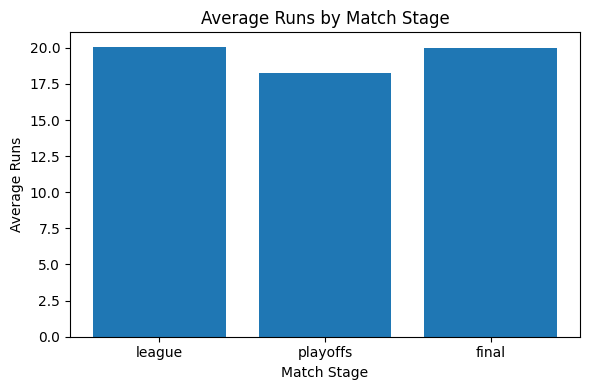

In [ ]:
stage_order = ["league", "playoffs", "final"]

avg_runs_stage = (
    batting_clean
    .groupby("stage_bucket")["runs"]
    .mean()
    .reindex(stage_order)
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(avg_runs_stage["stage_bucket"], avg_runs_stage["runs"])
plt.title("Average Runs by Match Stage")
plt.xlabel("Match Stage")
plt.ylabel("Average Runs")
plt.tight_layout()
plt.show()

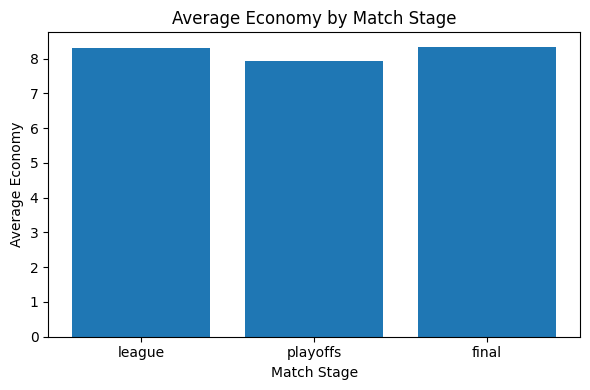

In [ ]:
avg_econ_stage = (
    bowling_clean
    .groupby("stage_bucket")["economy"]
    .mean()
    .reindex(stage_order)
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(avg_econ_stage["stage_bucket"], avg_econ_stage["economy"])
plt.title("Average Economy by Match Stage")
plt.xlabel("Match Stage")
plt.ylabel("Average Economy")
plt.tight_layout()
plt.show()

## 6) Save analysis-ready outputs

I save the cleaned datasets so future modeling notebooks can load them directly.
This keeps the workflow reproducible and avoids re-cleaning each time.

In [ ]:
out_dir = Path("data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

bat_out = out_dir / "batting_clean.csv"
bowl_out = out_dir / "bowling_clean.csv"

batting_clean.to_csv(bat_out, index=False)
bowling_clean.to_csv(bowl_out, index=False)

print("Saved:")
print(" -", bat_out.resolve())
print(" -", bowl_out.resolve())

Saved:
 - /content/data/processed/batting_clean.csv
 - /content/data/processed/bowling_clean.csv


In [ ]:
batting_clean = clean_batting(batting)
bowling_clean = clean_bowling(bowling)

In [ ]:
batting_clean.to_csv("data/processed/batting_clean.csv", index=False)
bowling_clean.to_csv("data/processed/bowling_clean.csv", index=False)

In [ ]:
print(batting_clean.shape)
print(bowling_clean.shape)

(16515, 11)
(12978, 17)


In [ ]:
batting_clean.to_csv("batting_clean.csv", index=False)
bowling_clean.to_csv("bowling_clean.csv", index=False)

In [ ]:
from google.colab import files

files.download("batting_clean.csv")
files.download("bowling_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Module 7 — Data Wrangling Part II: Feature Engineering

In this module, we transform cleaned IPL player-match data into model-ready features.

The objective is not to create as many features as possible, but to create a defensible, interpretable, and reproducible feature set aligned with the prediction task.

Regression Goals:

- Batting Model → Predict runs scored
- Bowling Model → Predict economy rate

All historical aggregates are computed using expanding windows with shift() to prevent data leakage.

## Part II Focus: Features for Modeling and Insight

This stage implements:

- Categorical encoding (One-Hot Encoding for nominal variables)
- Numeric transformations (Z-score standardization)
- Derived features (ratios, rolling statistics, career aggregates)
- Date/time extraction (month, weekday)
- Feature selection (removal of identifiers and leakage-prone columns)
- Production of final model-ready feature tables

All decisions are documented and justified.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load cleaned datasets from Module 6
batting = pd.read_csv("data/processed/batting_clean.csv", parse_dates=["date"])
bowling = pd.read_csv("data/processed/bowling_clean.csv", parse_dates=["date"])

batting = batting.sort_values(["player", "date"])
bowling = bowling.sort_values(["bowler", "date"])

# Batting Feature Engineering (Regression)

Target Variable:
runs

Historical aggregates are computed using expanding means with shift() to avoid future information leakage.

In [ ]:
# Career aggregates
batting["career_avg_runs"] = (
    batting.groupby("player")["runs"]
    .expanding().mean().shift()
    .reset_index(level=0, drop=True)
)

batting["career_std_runs"] = (
    batting.groupby("player")["runs"]
    .expanding().std().shift()
    .reset_index(level=0, drop=True)
)

# Recent form
batting["last3_avg_runs"] = (
    batting.groupby("player")["runs"]
    .rolling(3).mean().shift()
    .reset_index(level=0, drop=True)
)

In [ ]:
batting["runs_per_ball"] = batting["runs"] / batting["balls"].replace(0, np.nan)

batting["pressure_flag"] = np.where(
    batting["stage_bucket"].isin(["playoffs", "final"]), 1, 0
)

batting["match_month"] = batting["date"].dt.month
batting["match_weekday"] = batting["date"].dt.weekday

## Categorical Encoding

The variable `stage_bucket` is nominal and has no ordinal meaning.
Therefore, One-Hot Encoding is applied.

In [ ]:
batting = pd.get_dummies(
    batting,
    columns=["stage_bucket"],
    drop_first=True
)

## Feature Selection (Batting)

Removed:
- match_id (identifier)
- player (kept separately for tracking)
- date
- venue
- match_type
- season

These were removed due to redundancy or leakage risk.

In [ ]:
batting_model = batting.drop(columns=[
    "match_id",
    "player",
    "date",
    "venue",
    "match_type",
    "season"
])

In [ ]:
scaler = StandardScaler()

numeric_cols_batting = [
    "balls",
    "strike_rate",
    "career_avg_runs",
    "career_std_runs",
    "last3_avg_runs",
    "runs_per_ball"
]

batting_model[numeric_cols_batting] = scaler.fit_transform(
    batting_model[numeric_cols_batting]
)

In [ ]:
y_batting = batting_model["runs"]
X_batting = batting_model.drop(columns=["runs"])

batting_model.to_csv("data/processed/batting_model_ready.csv", index=False)

# Bowling Feature Engineering (Regression)

Target Variable:
economy

Similar leakage-safe methodology is applied for bowling features.

In [ ]:
bowling["career_avg_econ"] = (
    bowling.groupby("bowler")["economy"]
    .expanding().mean().shift()
    .reset_index(level=0, drop=True)
)

bowling["career_std_econ"] = (
    bowling.groupby("bowler")["economy"]
    .expanding().std().shift()
    .reset_index(level=0, drop=True)
)

bowling["last3_avg_econ"] = (
    bowling.groupby("bowler")["economy"]
    .rolling(3).mean().shift()
    .reset_index(level=0, drop=True)
)

In [ ]:
bowling["runs_per_ball"] = bowling["runs_conceded"] / bowling["balls"].replace(0, np.nan)
bowling["wicket_rate"] = bowling["wickets"] / bowling["balls"].replace(0, np.nan)

bowling["pressure_flag"] = np.where(
    bowling["stage_bucket"].isin(["playoffs", "final"]), 1, 0
)

bowling["match_month"] = bowling["date"].dt.month
bowling["match_weekday"] = bowling["date"].dt.weekday

In [ ]:
bowling = pd.get_dummies(
    bowling,
    columns=["stage_bucket"],
    drop_first=True
)

In [ ]:
bowling_model = bowling.drop(columns=[
    "match_id",
    "bowler",
    "date",
    "venue",
    "match_type",
    "season"
])

In [ ]:
numeric_cols_bowling = [
    "runs_conceded",
    "balls",
    "career_avg_econ",
    "career_std_econ",
    "last3_avg_econ",
    "runs_per_ball"
]

bowling_model[numeric_cols_bowling] = scaler.fit_transform(
    bowling_model[numeric_cols_bowling]
)

In [ ]:
y_bowling = bowling_model["economy"]
X_bowling = bowling_model.drop(columns=["economy"])

bowling_model.to_csv("data/processed/bowling_model_ready.csv", index=False)

## Before vs After Summary

Feature engineering reduced identifier-based columns and created structured historical aggregates.

Model-ready datasets:
- batting_model_ready.csv
- bowling_model_ready.csv

Both contain:
- Encoded categorical variables
- Scaled numeric features
- Leakage-safe historical aggregates
- Continuous regression targets

In [ ]:
print("Batting model columns:", len(batting_model.columns))
print("Bowling model columns:", len(bowling_model.columns))

Batting model columns: 13
Bowling model columns: 20


## Correlation Analysis

To better understand feature relationships and detect redundancy,
a correlation matrix was computed for numeric variables in both
batting and bowling model-ready datasets.

This helps:

- Identify multicollinearity
- Detect redundant features
- Justify feature selection
- Understand relationships with target variables

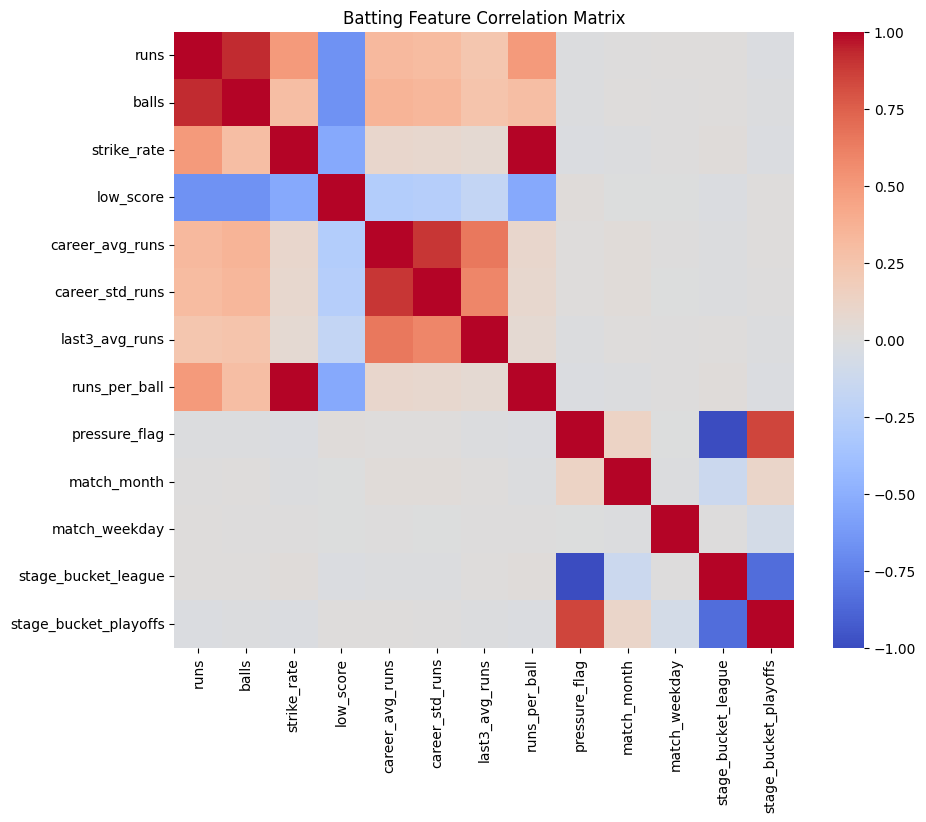

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    batting_model.corr(),
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Batting Feature Correlation Matrix")
plt.show()

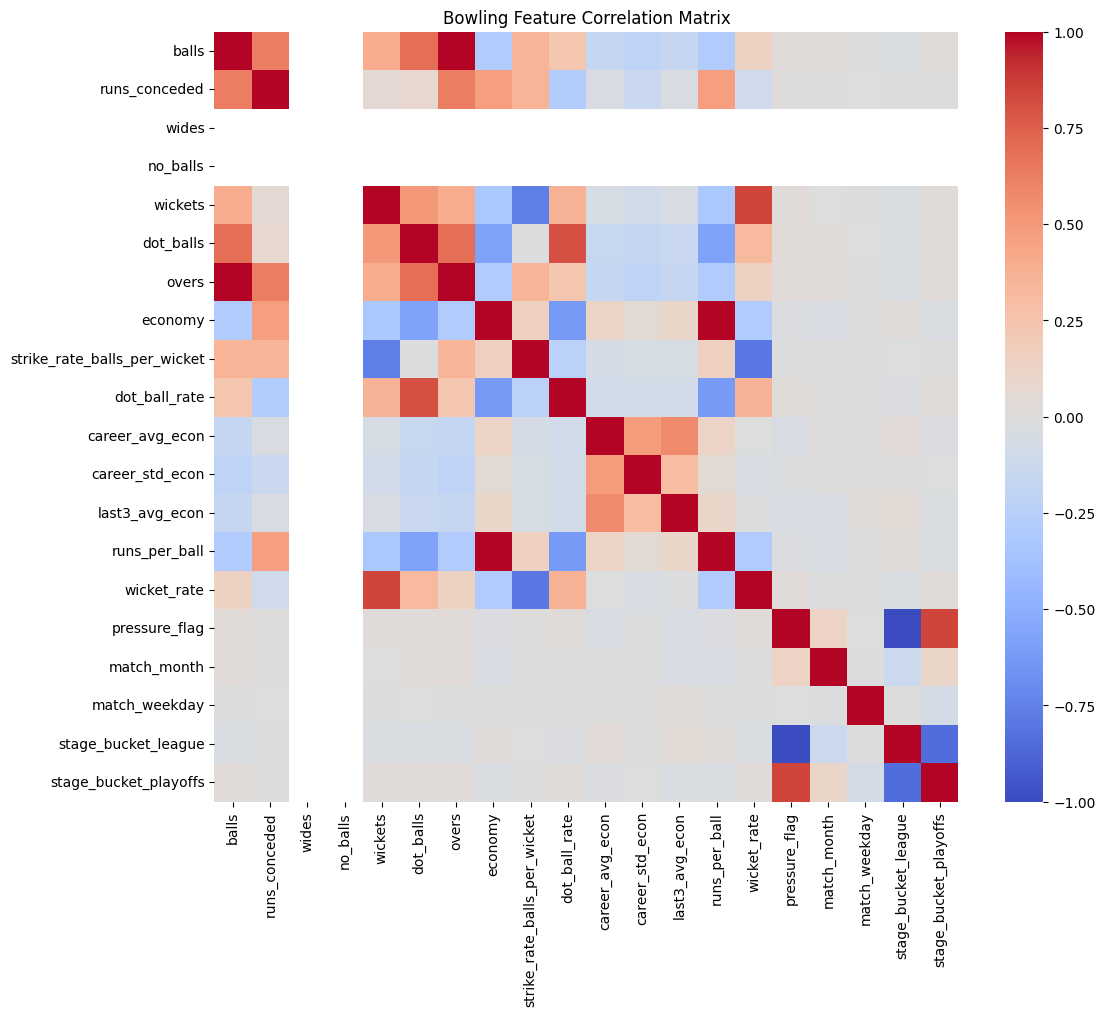

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    bowling_model.corr(),
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Bowling Feature Correlation Matrix")
plt.show()

In [ ]:
batting_corr_target = batting_model.corr()["runs"].sort_values(ascending=False)
print(batting_corr_target)

runs                     1.000000
balls                    0.929216
strike_rate              0.494818
runs_per_ball            0.494818
career_avg_runs          0.320409
career_std_runs          0.304998
last3_avg_runs           0.237756
stage_bucket_league      0.014979
match_weekday            0.008885
match_month              0.001247
pressure_flag           -0.014979
stage_bucket_playoffs   -0.017227
low_score               -0.667237
Name: runs, dtype: float64


In [ ]:
bowling_corr_target = bowling_model.corr()["economy"].sort_values(ascending=False)
print(bowling_corr_target)

runs_per_ball                   1.000000
economy                         1.000000
runs_conceded                   0.473022
strike_rate_balls_per_wicket    0.152907
career_avg_econ                 0.120753
last3_avg_econ                  0.106798
career_std_econ                 0.054341
stage_bucket_league             0.019131
match_weekday                   0.004630
pressure_flag                  -0.019131
stage_bucket_playoffs          -0.023621
match_month                    -0.032540
wicket_rate                    -0.294444
overs                          -0.296841
balls                          -0.296841
wickets                        -0.321761
dot_balls                      -0.573078
dot_ball_rate                  -0.624949
wides                                NaN
no_balls                             NaN
Name: economy, dtype: float64


=== FEATURE ENGINEERING REPORT ===

FEATURES CREATED:
  career_avg_runs / career_avg_econ
    → Player's historical average performance
    → Most predictive signal for future performance
    → Computed with expanding mean + shift() to prevent leakage

  career_std_runs / career_std_econ
    → Measures consistency — high std = unpredictable player
    → Relevant for risk analysis which is a project objective

  last3_avg_runs / last3_avg_econ
    → Recent form over last 3 matches
    → Captures hot/cold streaks better than career average alone

  runs_per_ball / wicket_rate
    → Efficiency ratios that normalise for different match lengths
    → More informative than raw counts alone

  pressure_flag
    → Binary indicator for playoffs/final matches
    → Directly aligned with the pressure analysis objective

  match_month / match_weekday
    → Temporal patterns — some months have different pitch conditions
    → Weekday may correlate with crowd pressure and scheduling

FEATURES REMOVED:
  match_id  → identifier, no predictive value
  player    → kept separately for tracking, not used as feature
  date      → replaced by extracted month and weekday
  venue     → high cardinality, removed to reduce noise
  match_type → redundant with stage_bucket
  season    → replaced by temporal features

ENCODING:
  stage_bucket → One-Hot Encoded (nominal variable, no ordinal meaning)
  drop_first=True to avoid multicollinearity

SCALING:
  StandardScaler applied to numeric features
  Ensures no single feature dominates due to scale differences